# 04 — Model Comparison

Extend the baseline by adding NLP features and tree-based models.

**Inputs:** `derived/features.parquet`, `data/merged_books.csv`, `derived/baseline_pipeline.pkl`  
**Outputs:** model comparison table, ROC curves

## Models

| Model | Features | Notes |
|-------|----------|-------|
| Logistic regression | Structural | From notebook 03 — the floor |
| LR + description length & sentiment | Structural + NLP-lite | Fast; no GPU needed |
| Random forest | Structural | Handles non-linearity; built-in feature importance |
| Gradient boosting | Structural | Typically stronger than RF on tabular data |
| LR + description embeddings | Structural + embeddings | sentence-transformers; GPU recommended |

All models use the same year-based split (cutoff from notebook 01).
Primary metric: **F1 (macro)**.  Also report ROC-AUC and precision/recall.

In [1]:
# pip install sentence-transformers

(7983, 32) (7983, 46)
Train: 5,244  Test: 2,723
=== Logistic Regression (baseline) ===
                precision    recall  f1-score   support

non-bestseller       0.94      0.79      0.86      2220
    bestseller       0.46      0.79      0.58       503

      accuracy                           0.79      2723
     macro avg       0.70      0.79      0.72      2723
  weighted avg       0.85      0.79      0.81      2723

F1 (macro): 0.721
ROC-AUC: 0.859


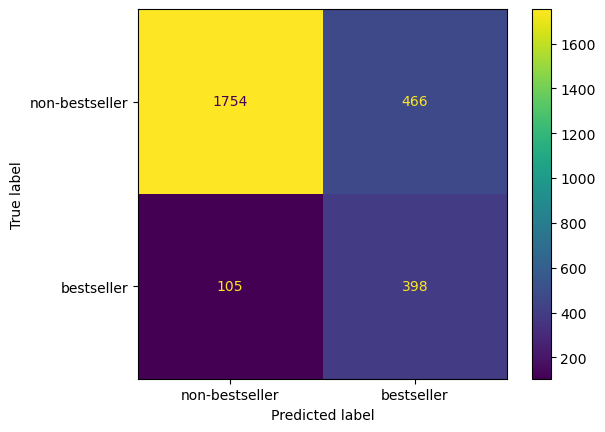

In [2]:
import sys
sys.path.insert(0, '..')

import torch
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import RocCurveDisplay
from sklearn.metrics import f1_score, precision_score, recall_score

from models.baseline import year_split
from models.evaluate import evaluate_model, compare_models
from features.build_features import (
    description_length,
    description_sentiment,
    description_embeddings,
    build_all_features,
)

TARGET_COL  = 'nyt_bestseller'
CUTOFF_YEAR = 2010  # match notebook 03

DATA_DIR    = Path('..') / 'data'
DERIVED_DIR = Path('..') / 'derived'
RESULTS_DIR = Path('..') / 'results'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

X        = pd.read_parquet(DERIVED_DIR / 'features.parquet')
df       = pd.read_csv(DATA_DIR / 'merged_books.csv')
baseline = joblib.load(DERIVED_DIR / 'baseline_pipeline.pkl')

# Rebuild the same split as 03 -- fresh kernel here, so this needs redoing
merged = X.merge(df[['gb_id', 'pub_year', TARGET_COL]], on='gb_id', how='inner')
feature_cols = [c for c in X.columns if c != 'gb_id']
X_train, y_train, X_test, y_test = year_split(merged, feature_cols, TARGET_COL, CUTOFF_YEAR)
print(X.shape, df.shape)
print(f'Train: {len(X_train):,}  Test: {len(X_test):,}')

# Evaluate the already-fitted baseline on this notebook's own test split,
# so it can be compared against every model built below in Section 5
baseline_result = evaluate_model(
    baseline, X_test, y_test, 'Logistic Regression (baseline)',
    save_path=RESULTS_DIR / '04_confusion_matrix_baseline_recheck.png',
)

## 1. Add description length & VADER sentiment

=== LR + description NLP-lite ===
                precision    recall  f1-score   support

non-bestseller       0.94      0.80      0.86      2220
    bestseller       0.46      0.78      0.58       503

      accuracy                           0.79      2723
     macro avg       0.70      0.79      0.72      2723
  weighted avg       0.85      0.79      0.81      2723

F1 (macro): 0.723
ROC-AUC: 0.857


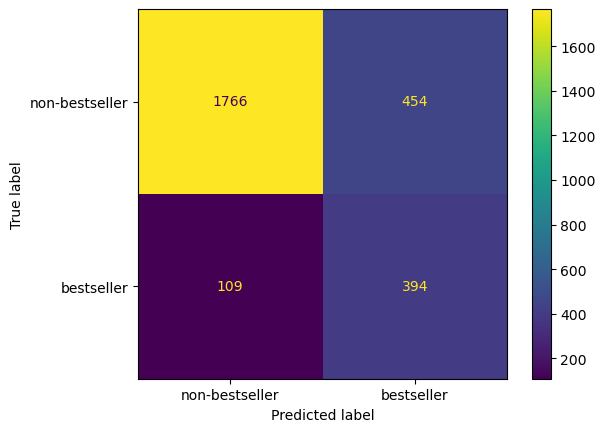

In [3]:
sent_feat = description_sentiment(df)  # desc_neg, desc_neu, desc_pos, desc_compound

X_nlp = merged.copy()
sent_with_id = sent_feat.copy()
sent_with_id['gb_id'] = df['gb_id']
X_nlp = X_nlp.merge(sent_with_id, on='gb_id', how='inner')

nlp_feature_cols = feature_cols + ['desc_neg', 'desc_neu', 'desc_pos', 'desc_compound']
X_train_nlp, y_train_nlp, X_test_nlp, y_test_nlp = year_split(
    X_nlp, nlp_feature_cols, TARGET_COL, CUTOFF_YEAR
)

pipeline_nlp = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=1000, class_weight="balanced")),
])
pipeline_nlp.fit(X_train_nlp, y_train_nlp)

result_lr_nlp = evaluate_model(
    pipeline_nlp, X_test_nlp, y_test_nlp, 'LR + description NLP-lite',
    save_path=RESULTS_DIR / '04_confusion_matrix_lr_nlp.png',
)

## 2. Random forest

=== Random Forest ===
                precision    recall  f1-score   support

non-bestseller       0.91      0.92      0.91      2220
    bestseller       0.62      0.58      0.60       503

      accuracy                           0.86      2723
     macro avg       0.76      0.75      0.76      2723
  weighted avg       0.85      0.86      0.86      2723

F1 (macro): 0.756
ROC-AUC: 0.869


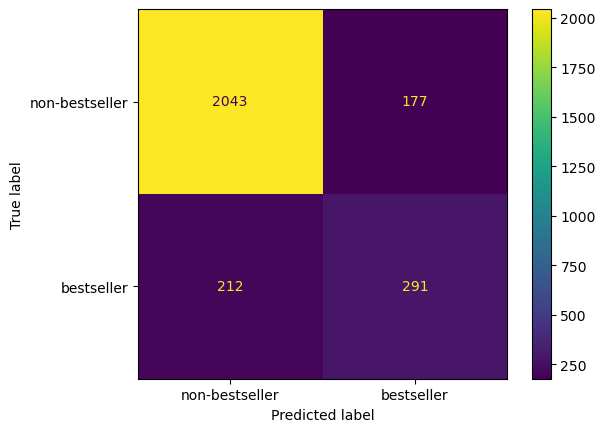

In [4]:
from sklearn.ensemble import RandomForestClassifier

pipeline_rf = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("clf", RandomForestClassifier(
        n_estimators=300, class_weight="balanced", random_state=42
    )),
])
pipeline_rf.fit(X_train, y_train)

result_rf = evaluate_model(
    pipeline_rf, X_test, y_test, 'Random Forest',
    save_path=RESULTS_DIR / '04_confusion_matrix_rf.png',
)

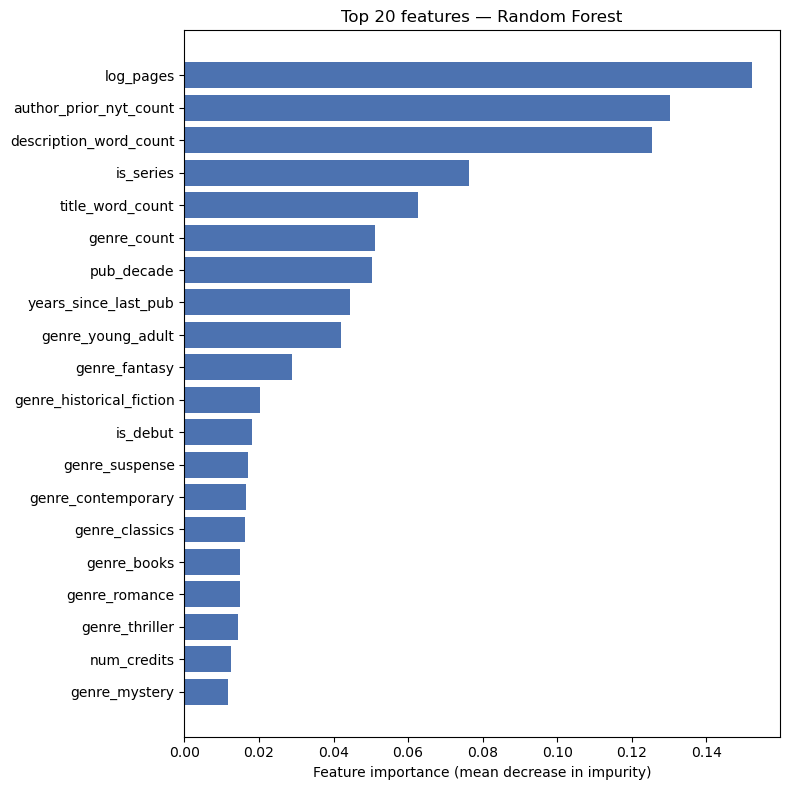

                 feature  importance
               log_pages    0.152120
  author_prior_nyt_count    0.130236
  description_word_count    0.125366
               is_series    0.076365
        title_word_count    0.062780
             genre_count    0.051060
              pub_decade    0.050329
    years_since_last_pub    0.044432
       genre_young_adult    0.042115
           genre_fantasy    0.028961
genre_historical_fiction    0.020205
                is_debut    0.018215
          genre_suspense    0.017143
      genre_contemporary    0.016595
          genre_classics    0.016174
             genre_books    0.014906
           genre_romance    0.014849
          genre_thriller    0.014400
             num_credits    0.012421
           genre_mystery    0.011816


In [5]:
# Feature importance plot, compared against 03's coefficients

importances = pipeline_rf.named_steps['clf'].feature_importances_
imp_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': importances,
}).sort_values('importance', ascending=False)

top20_rf = imp_df.head(20)

fig, ax = plt.subplots(figsize=(8, 8))
ax.barh(top20_rf['feature'][::-1], top20_rf['importance'][::-1], color='#4C72B0')
ax.set_xlabel('Feature importance (mean decrease in impurity)')
ax.set_title('Top 20 features — Random Forest')
plt.tight_layout()
plt.savefig(RESULTS_DIR / '04_rf_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print(top20_rf.to_string(index=False))

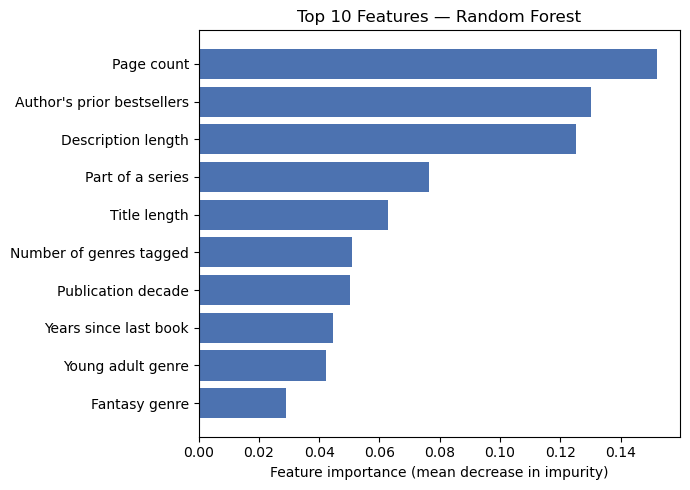

In [6]:
# ── Presentation chart 3: RF feature importance, top 10 ────────────────────
# top10_rf = imp_df.head(10)

# fig, ax = plt.subplots(figsize=(7, 5))
# ax.barh(top10_rf['feature'][::-1], top10_rf['importance'][::-1], color='#4C72B0')
# ax.set_xlabel('Feature importance (mean decrease in impurity)')
# ax.set_title('Top 10 Features — Random Forest')
# plt.tight_layout()
# plt.savefig(RESULTS_DIR / '04_rf_importance_top10.png', dpi=150, bbox_inches='tight')
# plt.show()

# ── Presentation chart 3: RF feature importance, top 10 (plain-language labels) ──
top10_rf = imp_df.head(10).copy()

label_map = {
    'log_pages': 'Page count',
    'author_prior_nyt_count': "Author's prior bestsellers",
    'description_word_count': 'Description length',
    'is_series': 'Part of a series',
    'title_word_count': 'Title length',
    'genre_count': 'Number of genres tagged',
    'pub_decade': 'Publication decade',
    'years_since_last_pub': 'Years since last book',
    'genre_young_adult': 'Young adult genre',
    'genre_fantasy': 'Fantasy genre',
}
top10_rf['label'] = top10_rf['feature'].map(label_map).fillna(top10_rf['feature'])

fig, ax = plt.subplots(figsize=(7, 5))
ax.barh(top10_rf['label'][::-1], top10_rf['importance'][::-1], color='#4C72B0')
ax.set_xlabel('Feature importance (mean decrease in impurity)')
ax.set_title('Top 10 Features — Random Forest')
plt.tight_layout()
plt.savefig(RESULTS_DIR / '04_rf_importance_top10.png', dpi=200, bbox_inches='tight')
plt.show()

## 3. Gradient boosting

=== Gradient Boosting ===
                precision    recall  f1-score   support

non-bestseller       0.94      0.82      0.88      2220
    bestseller       0.49      0.79      0.61       503

      accuracy                           0.81      2723
     macro avg       0.72      0.80      0.74      2723
  weighted avg       0.86      0.81      0.83      2723

F1 (macro): 0.742
ROC-AUC: 0.869


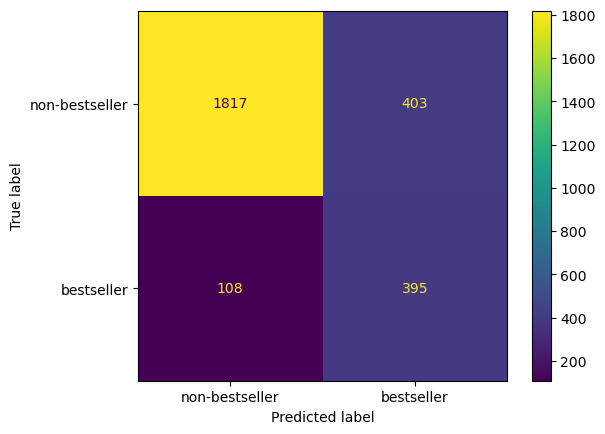

In [7]:
from sklearn.ensemble import GradientBoostingClassifier

# Compute per-sample weights to mimic class_weight='balanced'
# (inverse class frequency, same principle sklearn uses internally)
n_pos = y_train.sum()
n_neg = len(y_train) - n_pos
weight_pos = len(y_train) / (2 * n_pos)
weight_neg = len(y_train) / (2 * n_neg)
sample_weight = y_train.map({0: weight_neg, 1: weight_pos})

pipeline_gb = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("clf", GradientBoostingClassifier(random_state=42)),
])
pipeline_gb.fit(X_train, y_train, clf__sample_weight=sample_weight)

result_gb = evaluate_model(
    pipeline_gb, X_test, y_test, 'Gradient Boosting',
    save_path=RESULTS_DIR / '04_confusion_matrix_gb.png',
)

**Hyperparameter tuning attempt:**
A small grid search over max_depth/learning_rate, validated on a temporal slice of the training
years (2005–2009) and selected using macro-F1 (matching the project's primary metric throughout,
unlike an earlier version of this tuning pass which selected on bestseller-F1 inconsistently).
Best params: max_depth=2, learning_rate=0.2.

Result: **tuning made no meaningful difference** — tuned and untuned Gradient Boosting both land
at F1(macro)=0.742, with precision/recall differing only in the third decimal. The untuned model is used in the
final comparison for simplicity, since there's no performance reason to prefer either.

In [8]:
# ── Quick grid search for Gradient Boosting — tuned on a slice of TRAIN years only ──
# Never touches the real 2010+ test set during tuning (avoids "overfitting the split").

TUNE_CUTOFF = 2005  # tune-train: pub_year < 2005; tune-val: 2005 <= pub_year < 2010

train_only = merged[merged['pub_year'] < CUTOFF_YEAR]
X_tune_train, y_tune_train, X_tune_val, y_tune_val = year_split(
    train_only, feature_cols, TARGET_COL, TUNE_CUTOFF
)
print(f'Tune-train: {len(X_tune_train):,} rows, {y_tune_train.sum()} positives')
print(f'Tune-val:   {len(X_tune_val):,} rows, {y_tune_val.sum()} positives')

def make_sample_weight(y):
    """Mimic class_weight='balanced' via sample_weight (GB has no class_weight param)."""
    n_pos, n_neg = y.sum(), len(y) - y.sum()
    w_pos, w_neg = len(y) / (2 * n_pos), len(y) / (2 * n_neg)
    return y.map({0: w_neg, 1: w_pos})

param_grid = [{'max_depth': d, 'learning_rate': lr}
              for d in [2, 3, 4] for lr in [0.05, 0.1, 0.2]]

results_grid = []
for params in param_grid:
    imputer = SimpleImputer(strategy="median")
    X_tt_imp = imputer.fit_transform(X_tune_train)
    X_tv_imp = imputer.transform(X_tune_val)

    clf = GradientBoostingClassifier(random_state=42, **params)
    clf.fit(X_tt_imp, y_tune_train, sample_weight=make_sample_weight(y_tune_train))

    f1_val = f1_score(y_tune_val, clf.predict(X_tv_imp), average='macro')
    results_grid.append({**params, 'f1_val': f1_val})

grid_df = pd.DataFrame(results_grid).sort_values('f1_val', ascending=False)
print(grid_df.to_string(index=False))

best_params = grid_df.iloc[0][['max_depth', 'learning_rate']].to_dict()
best_params['max_depth'] = int(best_params['max_depth'])
print(f'\nBest params: {best_params}')

Tune-train: 3,680 rows, 577 positives
Tune-val:   1,564 rows, 315 positives
 max_depth  learning_rate   f1_val
         2           0.20 0.697547
         3           0.20 0.694919
         4           0.20 0.694557
         2           0.10 0.686558
         3           0.10 0.686523
         4           0.05 0.685458
         3           0.05 0.683557
         4           0.10 0.680308
         2           0.05 0.672148

Best params: {'max_depth': 2, 'learning_rate': 0.2}


=== Gradient Boosting (tuned) ===
                precision    recall  f1-score   support

non-bestseller       0.95      0.81      0.88      2220
    bestseller       0.49      0.80      0.61       503

      accuracy                           0.81      2723
     macro avg       0.72      0.81      0.74      2723
  weighted avg       0.86      0.81      0.83      2723

F1 (macro): 0.742
ROC-AUC: 0.867


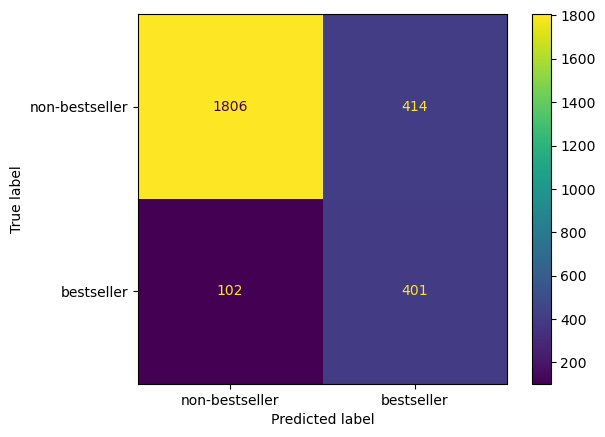

In [9]:
pipeline_gb_tuned = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("clf", GradientBoostingClassifier(random_state=42, **best_params)),
])
pipeline_gb_tuned.fit(X_train, y_train, clf__sample_weight=make_sample_weight(y_train))

result_gb_tuned = evaluate_model(
    pipeline_gb_tuned, X_test, y_test, 'Gradient Boosting (tuned)',
    save_path=RESULTS_DIR / '04_confusion_matrix_gb_tuned.png',
)

## 4. Description embeddings (optional — GPU recommended)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Batches:   0%|          | 0/250 [00:00<?, ?it/s]

Embedding shape: (7983, 384)
Train: 5,244 rows x 415 features
=== LR + description embeddings ===
                precision    recall  f1-score   support

non-bestseller       0.93      0.79      0.85      2220
    bestseller       0.44      0.72      0.54       503

      accuracy                           0.78      2723
     macro avg       0.68      0.75      0.70      2723
  weighted avg       0.84      0.78      0.79      2723

F1 (macro): 0.698
ROC-AUC: 0.832


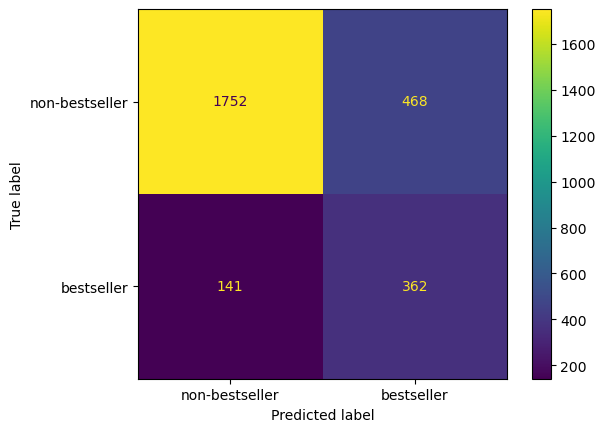

In [10]:
embeddings = description_embeddings(df, model_name='all-MiniLM-L6-v2')
print('Embedding shape:', embeddings.shape)

emb_df = pd.DataFrame(
    embeddings,
    columns=[f'desc_emb_{i}' for i in range(embeddings.shape[1])]
)
emb_df['gb_id'] = df['gb_id'].values

# Same merge pattern as Section 1 (structural features + this new block, joined on gb_id)
X_emb = merged.merge(emb_df, on='gb_id', how='inner')
emb_feature_cols = feature_cols + [f'desc_emb_{i}' for i in range(embeddings.shape[1])]

X_train_emb, y_train_emb, X_test_emb, y_test_emb = year_split(
    X_emb, emb_feature_cols, TARGET_COL, CUTOFF_YEAR
)
print(f'Train: {len(X_train_emb):,} rows x {len(emb_feature_cols)} features')

pipeline_emb = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=1000, class_weight="balanced")),
])
pipeline_emb.fit(X_train_emb, y_train_emb)

result_emb = evaluate_model(
    pipeline_emb, X_test_emb, y_test_emb, 'LR + description embeddings',
    save_path=RESULTS_DIR / '04_confusion_matrix_lr_embeddings.png',
)

## 5. Comparison table & ROC curves

In [11]:
# Collect all evaluate_model results into a list
# print(compare_models([baseline_result, lr_nlp_result, rf_result, gb_result, emb_result]))

# Sanity check: all model variants should share the same test-row count,
# since they're all inner-joined from the same base df on gb_id
assert len(X_test) == len(X_test_nlp) == len(X_test_emb), \
    "Test set sizes differ across model variants — check the merges."

naive_results = [
    {
        'model': 'Always-0',
        'f1_macro': f1_score(y_test, np.zeros_like(y_test), average='macro', zero_division=0),
        'precision': precision_score(y_test, np.zeros_like(y_test), zero_division=0),
        'recall': recall_score(y_test, np.zeros_like(y_test), zero_division=0),
        'roc_auc': None,
    },
    {
        'model': 'Always-1',
        'f1_macro': f1_score(y_test, np.ones_like(y_test), average='macro', zero_division=0),
        'precision': precision_score(y_test, np.ones_like(y_test), zero_division=0),
        'recall': recall_score(y_test, np.ones_like(y_test), zero_division=0),
        'roc_auc': None,
    },
]

# Using the UNTUNED GradientBoosting result (result_gb) -- the tuned version
# underperformed on the real test set and was discarded (documented separately).
all_results = naive_results + [
    baseline_result,
    result_lr_nlp,
    result_rf,
    result_gb,
    result_emb,
]

comparison_all = compare_models(all_results)
print(comparison_all.to_string(index=False))

comparison_all.to_csv(RESULTS_DIR / '04_model_comparison.csv', index=False)
print("\nSaved comparison table to results/04_model_comparison.csv")

                         model  f1_macro  precision   recall  roc_auc
                 Random Forest  0.756227   0.621795 0.578529 0.869334
             Gradient Boosting  0.741972   0.494987 0.785288 0.868733
     LR + description NLP-lite  0.722893   0.464623 0.783300 0.857220
Logistic Regression (baseline)  0.721156   0.460648 0.791252 0.859244
   LR + description embeddings  0.697534   0.436145 0.719682 0.832437
                      Always-0  0.449120   0.000000 0.000000      NaN
                      Always-1  0.155921   0.184723 1.000000      NaN

Saved comparison table to results/04_model_comparison.csv


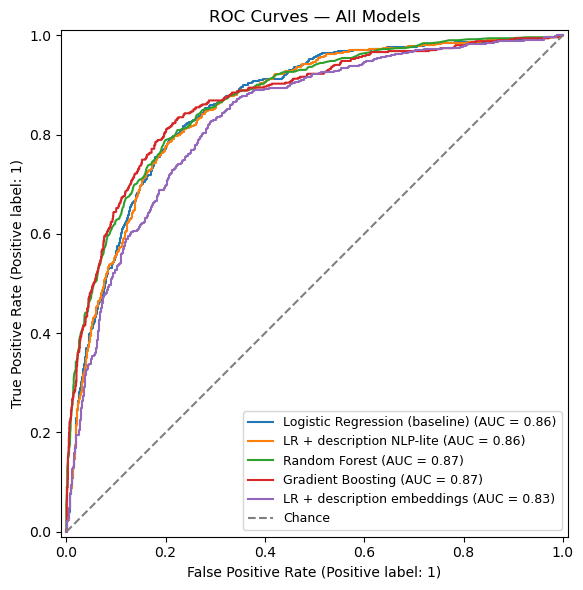

In [12]:
# Plot overlaid ROC curves with model names in the legend
# fig, ax = plt.subplots(figsize=(8, 6))
# for model, name in [(pipeline, 'LR baseline'), ...]:
#     RocCurveDisplay.from_estimator(model, X_test, y_test, ax=ax, name=name)

fig, ax = plt.subplots(figsize=(8, 6))

# Naive baselines deliberately excluded: a fixed-prediction rule has no
# threshold to sweep, so there's no meaningful ROC curve for them --
# they're only comparable in the table above, not this plot.
roc_models = [
    (baseline,      X_test,     y_test,     'Logistic Regression (baseline)'),
    (pipeline_nlp,  X_test_nlp, y_test_nlp, 'LR + description NLP-lite'),
    (pipeline_rf,   X_test,     y_test,     'Random Forest'),
    (pipeline_gb,   X_test,     y_test,     'Gradient Boosting'),
    (pipeline_emb,  X_test_emb, y_test_emb, 'LR + description embeddings'),
]

for model, Xt, yt, name in roc_models:
    RocCurveDisplay.from_estimator(model, Xt, yt, ax=ax, name=name)

ax.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Chance')
ax.set_title('ROC Curves — All Models')
ax.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.savefig(RESULTS_DIR / '04_roc_curves_all_models.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Comparison figures

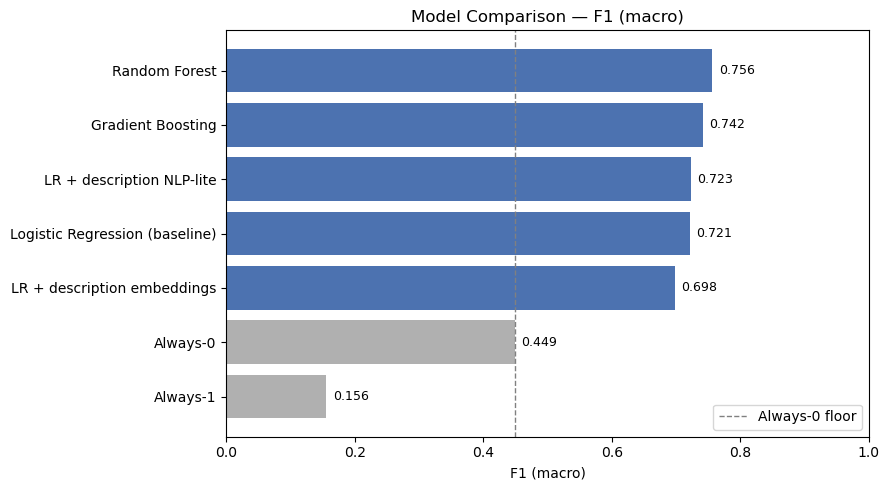

In [13]:
# ── Presentation chart 1: model comparison, macro-F1 only ──────────────────
fig, ax = plt.subplots(figsize=(9, 5))

colors = ['#4C72B0' if m not in ['Always-0', 'Always-1'] else '#B0B0B0'
          for m in comparison_all['model']]
bars = ax.barh(comparison_all['model'][::-1], comparison_all['f1_macro'][::-1], color=colors[::-1])

ax.set_xlabel('F1 (macro)')
ax.set_xlim(0, 1)
ax.set_title('Model Comparison — F1 (macro)')
ax.axvline(comparison_all.loc[comparison_all['model'] == 'Always-0', 'f1_macro'].values[0],
           color='gray', linestyle='--', linewidth=1, label='Always-0 floor')
ax.legend(loc='lower right')

# Label each bar with its value
for bar in bars:
    w = bar.get_width()
    ax.text(w + 0.01, bar.get_y() + bar.get_height()/2, f'{w:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig(RESULTS_DIR / '04_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

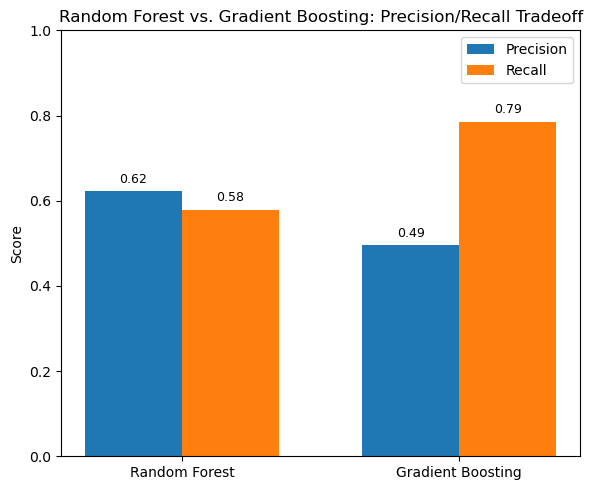

In [14]:
# ── Presentation chart 2: RF vs GB precision/recall tradeoff ───────────────
compare_two = comparison_all[comparison_all['model'].isin(['Random Forest', 'Gradient Boosting'])]

metrics = ['precision', 'recall']
x = np.arange(len(compare_two))
width = 0.35

fig, ax = plt.subplots(figsize=(6, 5))
for i, m in enumerate(metrics):
    bars = ax.bar(x + i * width, compare_two[m], width, label=m.capitalize())
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.02, f'{h:.2f}', ha='center', fontsize=9)

ax.set_xticks(x + width/2)
ax.set_xticklabels(compare_two['model'])
ax.set_ylabel('Score')
ax.set_ylim(0, 1)
ax.set_title('Random Forest vs. Gradient Boosting: Precision/Recall Tradeoff')
ax.legend()
plt.tight_layout()
plt.savefig(RESULTS_DIR / '04_rf_gb_tradeoff.png', dpi=150, bbox_inches='tight')
plt.show()

## Summary

| Model | F1 (macro) | Precision | Recall | ROC-AUC |
|---|---|---|---|---|
| **Random Forest** | **0.756** | 0.62 | 0.58 | 0.869 |
| Gradient Boosting | 0.742 | 0.49 | 0.79 | 0.869 |
| LR + description NLP-lite | 0.723 | 0.46 | 0.78 | 0.857 |
| Logistic Regression (baseline) | 0.721 | 0.46 | 0.79 | 0.859 |
| LR + description embeddings | 0.698 | 0.44 | 0.72 | 0.832 |
| Always-1 (naive) | 0.156 | 0.18 | 1.00 | — |
| Always-0 (naive) | 0.449 | 0.00 | 0.00 | — |

- **Best model: Random Forest** (F1 macro=0.756), clearly ahead of every other model and well
  above the Always-0 naive floor (0.449) — a meaningful, non-trivial result.
- **GB tuning was neutral, not harmful** — tuned and untuned land within rounding of each other
  once both the tuning selection and final evaluation use the same metric (macro-F1).
- **Text-based features (NLP-lite, embeddings) do not clearly beat the structural baseline** —
  NLP-lite is statistically tied with it; embeddings underperform, likely due to overfitting
  (415 features vs. 5,244 training rows, a far higher ratio than any other model here).
- **`log_pages` is Random Forest's top feature even after removing box sets** — confirms this
  signal isn't merely a box-set artifact.

- **Key Takeaway - RF and GB have opposite precision/recall personalities, suited to different stakeholders.**
  RF is cautious: 62% precision, 58% recall — fewer false alarms, but misses more real hits.
  GB is aggressive: 49% precision, 79% recall — catches more hits, but flags many more false
  positives. 
  
  **RF fits budget-sensitive decisions** (e.g. marketing spend, print runs), where a
  wrong "yes" is costly. 
  
  **GB fits early-screening decisions** (e.g. acquisitions scouting),
  where missing a hidden hit is costlier than reviewing extra false positives. Neither is
  objectively better — the right pick depends on which mistake costs more in context.

**Next:** Checkpoint 5 — presentation and executive summary, built on Random Forest as the final
model.